In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

An overall "no significant lift" result can hide the fact that the redesign works great for one segment and poorly for another — those effects cancel out in the aggregate. This is called heterogeneous treatment effect analysis

In [2]:
df_clean=pd.read_csv(r"C:\Users\Pavitra\Downloads\AB_Testing_Project\notebooks\df_clean")

In [3]:
df_clean.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [4]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288689 entries, 0 to 288688
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       288689 non-null  int64 
 1   timestamp     288689 non-null  object
 2   group         288689 non-null  object
 3   landing_page  288689 non-null  object
 4   converted     288689 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.0+ MB


In [5]:
## Building Time Proxy as we do not have demographic data 

df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['hour'] = df_clean['timestamp'].dt.hour
def time_of_day(h):
    if 0 <= h < 6: return 'Night'
    elif 6 <= h < 12: return 'Morning'
    elif 12 <= h < 18: return 'Afternoon'
    else: return 'Evening'
df_clean['time_segment'] = df_clean['hour'].apply(time_of_day)

df_clean['day_type'] = df_clean['timestamp'].dt.dayofweek.apply(lambda d: 'Weekend' if d >= 5 else 'Weekday')

start_date = df_clean['timestamp'].min()
df_clean['experiment_week'] = ((df_clean['timestamp'] - start_date).dt.days // 7) + 1
df_clean['week_segment'] = df_clean['experiment_week'].apply(lambda w: 'Week 1' if w == 1 else 'Week 2+')

In [6]:
## Run the z-test independently within each segment

from statsmodels.stats.proportion import proportions_ztest

def segment_test(data, segment_col, segment_val):
    seg = data[data[segment_col] == segment_val]
    c = seg[seg['group']=='control']
    t = seg[seg['group']=='treatment']
    stat, p = proportions_ztest([t['converted'].sum(), c['converted'].sum()],
                                 [len(t), len(c)])
    return {
        'segment': segment_val, 'n_control': len(c), 'n_treatment': len(t),
        'control_rate': c['converted'].mean(), 'treatment_rate': t['converted'].mean(),
        'lift': t['converted'].mean() - c['converted'].mean(),
        'p_value': p
    }

results = []
for val in df_clean['time_segment'].unique():
    results.append(segment_test(df_clean, 'time_segment', val))
for val in df_clean['day_type'].unique():
    results.append(segment_test(df_clean, 'day_type', val))
for val in df_clean['week_segment'].unique():
    results.append(segment_test(df_clean, 'week_segment', val))

results_df = pd.DataFrame(results)
results_df

,segment,n_control,n_treatment,control_rate,treatment_rate,lift,p_value
0,Evening,36229,35932,0.119545,0.122481,0.002936,0.226573
1,Morning,36202,35913,0.122065,0.118704,-0.003362,0.165442
2,Afternoon,35871,36377,0.121017,0.119691,-0.001326,0.583912
3,Night,35998,36167,0.118590,0.114469,-0.004121,0.084504
4,Weekend,39595,39443,0.121935,0.117435,-0.004499,0.051363
5,Weekday,104705,104946,0.119689,0.119357,-0.000332,0.814737
6,Week 2+,98558,98302,0.120782,0.119377,-0.001405,0.337736
7,Week 1,45742,46087,0.119278,0.117669,-0.001609,0.450641


* The treatment effect was −0.161pp in Week 1 and −0.141pp in Week 2+, with neither effect statistically significant. Therefore, the segment analysis provides no evidence of a novelty-driven decay in treatment performance.
* Evening: +0.294pp — largest positive lift, but \(p=0.227\), so not significant.
* Morning: −0.336pp — largest negative lift, but \(p=0.165\), so not significant.
* Afternoon: −0.133pp, \(p=0.584\) → not significant.
* Night: −0.412pp, \(p=0.085\) → closest to significance, but still above 0.05.
* Weekend: −0.450pp, \(p=0.051\) → very close, but technically not significant at α=0.05.
* Weekday: −0.033pp, \(p=0.815\) → essentially no difference.

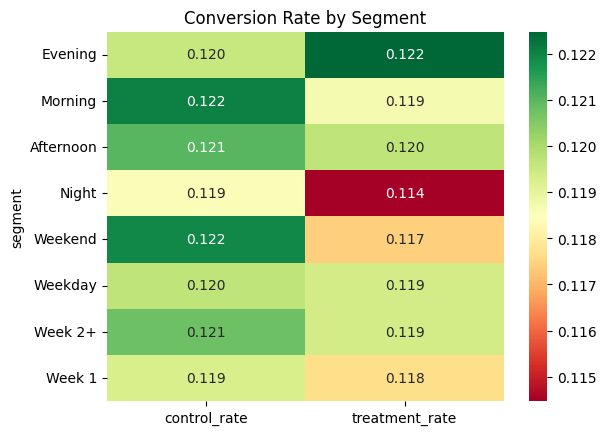

In [8]:
import seaborn as sns
pivot = results_df.set_index('segment')[['control_rate','treatment_rate']]
sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt='.3f')
plt.title('Conversion Rate by Segment')
plt.savefig('../exports/segment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**the new page shows a somewhat significant lift and conversion rate only in Evening , suggesting a targeted rollout rather than a full or zero rollout on trial basis.need to inspect further**

In [12]:
## checking the "Evening" segement specifically 

In [13]:
df_clean

,user_id,timestamp,group,landing_page,converted,hour,time_segment,day_type,experiment_week,week_segment
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,22,Evening,Weekend,3,Week 2+
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,8,Morning,Weekday,2,Week 2+
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,16,Afternoon,Weekday,2,Week 2+
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,18,Evening,Weekend,1,Week 1
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,1,Night,Weekend,3,Week 2+
...,...,...,...,...,...,...,...,...,...,...
288684,751197,2017-01-03 22:28:38.630509,control,old_page,0,22,Evening,Weekday,1,Week 1
288685,945152,2017-01-12 00:51:57.078372,control,old_page,0,0,Night,Weekday,2,Week 2+
288686,734608,2017-01-22 11:45:03.439544,control,old_page,0,11,Morning,Weekend,3,Week 2+
288687,697314,2017-01-15 01:20:28.957438,control,old_page,0,1,Night,Weekend,2,Week 2+


In [14]:
evening = df_clean[df_clean['time_segment'] == 'Evening']

control_evening = evening[evening['group'] == 'control']
treatment_evening = evening[evening['group'] == 'treatment']

successes = [
    treatment_evening['converted'].sum(),
    control_evening['converted'].sum()
]

n_obs = [
    len(treatment_evening),
    len(control_evening)
]

z_stat, p_value = proportions_ztest(
    successes,
    n_obs,
    alternative='two-sided'
)

print(f"Evening Control Rate: {control_evening['converted'].mean():.4f}")
print(f"Evening Treatment Rate: {treatment_evening['converted'].mean():.4f}")
print(f"Lift: {(treatment_evening['converted'].mean() - control_evening['converted'].mean()):.4f}")
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Evening Control Rate: 0.1195
Evening Treatment Rate: 0.1225
Lift: 0.0029
z-statistic: 1.2092
p-value: 0.2266


 ### Evening Segment — Rollout Decision

- Control conversion rate: **11.95%**
- Treatment conversion rate: **12.25%**
- Observed lift: **+0.29 percentage points**
- z-statistic: **1.2092**
- p-value: **0.2266**

The Evening segment shows a positive observed lift of 0.29pp, but the result is not statistically significant (p > 0.05). Therefore, there is insufficient evidence that the treatment genuinely improves conversion for Evening users.

**Decision: Do not recommend a targeted rollout even in the Evening segment.** The observed improvement could reasonably be due to random variation.